In [ ]:
%pip install pandas mplcyberpunk seaborn
import pandas as pd


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import os
import mplcyberpunk

# ══════════════════════════════════════════════════════════════
#  GLOBAL CONFIG  —  change these to update the whole notebook
# ══════════════════════════════════════════════════════════════

# ── Data ──────────────────────────────────────────────────────
DATA_DIR     = '.'    # folder containing the CSV files
TOP_N_FILTER = 100   # top N films per period kept for both datasets
TOP_N_GENRES = 6     # genres shown in trend & candlestick charts

# ── Periods ───────────────────────────────────────────────────
PERIOD_ORDER = ['2023-H1', '2023-H2', '2024-H1', '2024-H2', '2025-H1', '2025-H2']
START_PERIOD = '2023-H1'
END_PERIOD   = '2025-H2'

# ── Colors ────────────────────────────────────────────────────
C_BG         = '#000000'
C_GROWING    = '#00ff41'   # green candle / growing genre
C_DECLINING  = '#ff073a'   # red candle / declining genre
C_OPEN_CLOSE = '#ffffff'   # open/close tick marks on candles
C_INDO       = '#ff073a'   # Indonesia line color
C_GLOBAL     = '#00b4d8'   # Global line color
C_HIGHLIGHT  = '#ff073a'   # big-number callout accent
C_THRESHOLD  = '#ffdd00'   # threshold/benchmark line
C_ACTUAL     = '#00b4d8'   # actual-data bars
C_PROJECTED  = '#ff9f1c'   # projected-data bars
C_MUTED      = '#888888'   # greyed-out / COVID bar / muted text

REGION_PALETTE = {'Indonesia': C_INDO, 'Global': C_GLOBAL}

# ── Typography ────────────────────────────────────────────────
FS_TITLE  = 28
FS_LABEL  = 24
FS_TICK   = 20
FS_LEGEND = 20
FS_TEXT   = 16

# ── Figure ────────────────────────────────────────────────────
FIG_W = 19.2
FIG_H = 10.8

# ── rcParams ──────────────────────────────────────────────────
mpl.rcParams.update({
    'figure.facecolor': C_BG,
    'axes.facecolor':   C_BG,
    'font.size':        FS_TEXT,
    'font.family':      'Roboto',
    'figure.dpi':       100,
    'savefig.dpi':      100,
})

# ── Helpers ───────────────────────────────────────────────────
def fmt_millions(x, pos=None):
    return f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:,.1f}M'

def new_fig(w=FIG_W, h=FIG_H):
    plt.style.use('cyberpunk')
    fig, ax = plt.subplots(figsize=(w, h))
    fig.set_facecolor(C_BG); ax.set_facecolor(C_BG)
    return fig, ax

def finish_plot(fig=None, tight=True, glow=True):
    f = fig or plt.gcf()
    f.set_facecolor(C_BG)
    for ax in f.get_axes():
        ax.set_facecolor(C_BG)
    if tight:
        plt.tight_layout()
    if glow:
        try: mplcyberpunk.add_glow_effects()
        except Exception: pass
    plt.show()

print(f'Config loaded | periods={PERIOD_ORDER} | top_n_filter={TOP_N_FILTER}')


Config loaded | periods=['2023-H1', '2023-H2', '2024-H1', '2024-H2', '2025-H1', '2025-H2'] | top_n_filter=100


# **Loading**

In [ ]:
# ── CSV file map — update filenames here if they change ──────
INDONESIA_FILES = {
    ('2023', 'H1'): 'flixpatrol_indonesia_movies_H1_2023.csv',
    ('2023', 'H2'): 'flixpatrol_indonesia_movies_H2_2023.csv',
    ('2024', 'H1'): 'flixpatrol_indonesia_2024_H1.csv',
    ('2024', 'H2'): 'flixpatrol_indonesia_2024_H2.csv',
    ('2025', 'H1'): 'flixpatrol_indonesia_2025_H1.csv',
    ('2025', 'H2'): 'flixpatrol_indonesia_2025_H2.csv',
}

GLOBAL_FILES = {
    ('2023', 'H1'): 'flixpatrol_global_2023_H1.csv',
    ('2023', 'H2'): 'flixpatrol_global_2023_H2.csv',
    ('2024', 'H1'): 'flixpatrol_global_2024_H1.csv',
    ('2024', 'H2'): 'flixpatrol_global_2024_H2.csv',
    ('2025', 'H1'): 'flixpatrol_global_2025_H1.csv',
    ('2025', 'H2'): 'flixpatrol_global_2025_H2.csv',
}

def load_and_tag(file_map, data_dir=DATA_DIR):
    frames = []
    for (year, half), filename in file_map.items():
        df = pd.read_csv(os.path.join(data_dir, filename))
        df['data_year'] = int(year)
        df['half_year'] = half
        df['period']    = f'{year}-{half}'
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

raw_indo   = load_and_tag(INDONESIA_FILES)
raw_global = load_and_tag(GLOBAL_FILES)
print(f'Loaded  |  Indonesia: {len(raw_indo):,} rows  |  Global: {len(raw_global):,} rows')


Loaded  |  Indonesia: 1,262 rows  |  Global: 599 rows


# **Functions**

In [ ]:
def aggregate_views(raw_df, top_n=TOP_N_FILTER):
    """Filter to top N films per period, aggregate views by genre+period."""
    df = raw_df.copy()
    df['rank'] = df.groupby('period', observed=False)['views'].rank(method='dense', ascending=False)
    df = df[df['rank'] <= top_n].drop(columns=['rank'])
    agg = df.groupby(['genre', 'period'], observed=False)['views'].sum().reset_index()
    agg['period'] = pd.Categorical(agg['period'], categories=PERIOD_ORDER, ordered=True)
    return agg.sort_values('period').reset_index(drop=True)

views_indo   = aggregate_views(raw_indo)
views_global = aggregate_views(raw_global)

# Validation pivot tables
print(f'Indonesia — top {TOP_N_FILTER} films per period:')
display(views_indo.pivot(index='genre', columns='period', values='views')
        .fillna(0).astype(int).style.format('{:,}'))

print(f'\nGlobal — top {TOP_N_FILTER} films per period:')
display(views_global.pivot(index='genre', columns='period', values='views')
        .fillna(0).astype(int).style.format('{:,}'))


Indonesia — top 100 films per period:


period,2023-H1,2023-H2,2024-H1,2024-H2,2025-H1,2025-H2
genre,,,,,,
Action,"20,600,000","13,300,000","6,500,000","37,000,000","16,400,000","14,800,000"
Adventure,"900,000","800,000","500,000","3,300,000","4,300,000","2,600,000"
Animation,0,0,0,"200,000","200,000","1,700,000"
Biography,"200,000","1,200,000","2,200,000","1,200,000","600,000","400,000"
Comedy,"7,400,000","6,200,000","11,200,000","13,700,000","31,300,000","15,300,000"
Crime,"1,600,000","400,000","4,400,000","1,200,000","900,000","3,600,000"
Documentary,0,"8,200,000","1,900,000","2,400,000","1,100,000","600,000"
Drama,"9,900,000","12,000,000","18,500,000","31,200,000","56,400,000","58,300,000"
Family,"100,000",0,0,0,0,0



Global — top 100 films per period:


period,2023-H1,2023-H2,2024-H1,2024-H2,2025-H1,2025-H2
genre,,,,,,
Action,"354,700,000","507,200,000","529,400,000","771,500,000","775,900,000","173,400,000"
Adventure,"199,200,000","151,900,000","221,500,000","90,500,000","140,700,000","84,800,000"
Animation,"936,966,000","995,300,000","1,152,800,000","1,027,900,000","1,050,800,000","1,274,200,000"
Comedy,"588,600,000","709,100,000","382,900,000","424,800,000","226,300,000","675,100,000"
Crime,"318,000,000","158,300,000","115,600,000","54,000,000","128,000,000","143,100,000"
Documentary,"71,700,000",0,"114,400,000","101,600,000","108,700,000","178,900,000"
Drama,"133,000,000","104,800,000","151,000,000","280,000,000","336,600,000","187,100,000"
Family,"112,800,000","130,600,000","25,700,000","135,300,000","191,700,000","90,700,000"
Fantasy,"18,900,000",0,0,"68,300,000","38,300,000",0


In [ ]:
def normalize_views(agg_df, region_label):
    """Add views_share column: genre views / total views per period."""
    totals = agg_df.groupby('period', observed=False)['views'].sum().reset_index(name='total_views')
    df = agg_df.merge(totals, on='period')
    df['views_share'] = df['views'] / df['total_views']
    df['region'] = region_label
    return df

views_indo_norm   = normalize_views(views_indo,   'Indonesia')
views_global_norm = normalize_views(views_global, 'Global')

combined_norm = pd.concat([
    views_indo_norm[['genre', 'period', 'views_share', 'region']],
    views_global_norm[['genre', 'period', 'views_share', 'region']],
], ignore_index=True)

print('Normalization complete.')
display(combined_norm.head(12))


Normalization complete.


,genre,period,views_share,region
0,Action,2023-H1,0.389414,Indonesia
1,Drama,2023-H1,0.187146,Indonesia
2,Family,2023-H1,0.001890,Indonesia
3,Horror,2023-H1,0.179584,Indonesia
4,Crime,2023-H1,0.030246,Indonesia
5,Comedy,2023-H1,0.139887,Indonesia
6,Biography,2023-H1,0.003781,Indonesia
7,Science Fiction,2023-H1,0.001890,Indonesia
8,Thriller,2023-H1,0.018904,Indonesia
9,Romance,2023-H1,0.030246,Indonesia


In [ ]:
# ══════════════════════════════════════════════════════════════
#  CHART FUNCTIONS  —  reused across Indonesia & Global
# ══════════════════════════════════════════════════════════════

def plot_trend_lines(agg_df, title, top_n=TOP_N_GENRES):
    """Line chart of top N genres by total views."""
    top_list = (agg_df.groupby('genre', observed=False)['views'].sum()
                .sort_values(ascending=False).head(top_n).index.tolist())
    df_plot = agg_df[agg_df['genre'].isin(top_list)].copy()
    df_plot['genre'] = pd.Categorical(df_plot['genre'], categories=top_list, ordered=True)
    df_plot = df_plot.sort_values(['genre', 'period'])

    fig, ax = new_fig()
    sns.lineplot(data=df_plot, x='period', y='views', hue='genre',
                 marker='o', palette='tab10', linewidth=2.5, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=FS_TITLE)
    ax.set_xlabel('Period', fontsize=FS_LABEL)
    ax.set_ylabel('Total Views', fontsize=FS_LABEL)
    ax.tick_params(axis='both', labelsize=FS_TICK, rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left',
              fontsize=FS_LEGEND, title_fontsize=FS_LEGEND)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
    finish_plot(fig)


def plot_candlestick(agg_df, title, top_n=TOP_N_GENRES,
                     callouts=None, footnotes=None,
                     start=START_PERIOD, end=END_PERIOD):
    """
    Horizontal candlestick chart.

    Parameters
    ----------
    agg_df    : aggregated views DataFrame (genre, period, views)
    title     : chart title string
    top_n     : number of genres by total views
    callouts  : list of (header_text, value_text, color) for right-side panel
    footnotes : list of footnote strings for right-side panel
    start     : opening period (body left anchor)
    end       : closing period (body right anchor)

    Returns
    -------
    candle_df : DataFrame with open/close/high/low per genre
    """
    total     = agg_df.groupby('genre')['views'].sum().sort_values(ascending=False)
    top_genres = total.head(top_n).index.tolist()

    rows = []
    for g in top_genres:
        gdf    = agg_df[agg_df['genre'] == g]
        open_vals  = gdf[gdf['period'] == start]['views'].values
        close_vals = gdf[gdf['period'] == end]['views'].values
        open_  = open_vals[0]  if len(open_vals)  else 0
        close_ = close_vals[0] if len(close_vals) else 0
        rows.append({'genre': g,
                     'open':  open_,
                     'close': close_,
                     'high':  gdf['views'].max(),
                     'low':   gdf['views'].min(),
                     'total': total[g]})

    candle_df = (pd.DataFrame(rows)
                 .sort_values('total', ascending=True)
                 .reset_index(drop=True))

    has_panel = bool(callouts or footnotes)
    plt.style.use('cyberpunk')

    if has_panel:
        fig   = plt.figure(figsize=(FIG_W/3*2.3, FIG_H))
        ax     = fig.add_axes([0.05, 0.08, 0.58, 0.82])
        ax_ann = fig.add_axes([0.65, 0.08, 0.32, 0.82])
        ax_ann.set_xlim(0, 1); ax_ann.set_ylim(0, 1); ax_ann.axis('off')
        fig.set_facecolor(C_BG); ax_ann.set_facecolor(C_BG)
    else:
        fig, ax = plt.subplots(figsize=(FIG_W/3*2.3, FIG_H))

    fig.set_facecolor(C_BG); ax.set_facecolor(C_BG)

    for i, row in candle_df.iterrows():
        color  = C_GROWING if row['close'] >= row['open'] else C_DECLINING
        body_l = min(row['open'], row['close'])
        body_r = max(row['open'], row['close'])
        # Wick
        ax.plot([row['low'],  row['high']], [i, i],           color=color, lw=1.5, alpha=0.6, zorder=2)
        # Wick end-caps
        ax.plot([row['low'],  row['low']],  [i-0.25, i+0.25], color=color, lw=2,   alpha=0.8, zorder=2)
        ax.plot([row['high'], row['high']], [i-0.25, i+0.25], color=color, lw=2,   alpha=0.8, zorder=2)
        # Body
        ax.barh(i, body_r - body_l, left=body_l, height=0.55, color=color, alpha=0.9, zorder=3)
        # Open / close ticks
        ax.plot([row['open'],  row['open']],  [i-0.35, i+0.35], color=C_OPEN_CLOSE, lw=1.5, zorder=4)
        ax.plot([row['close'], row['close']], [i-0.35, i+0.35], color=C_OPEN_CLOSE, lw=1.5, zorder=4)
        # Inline label
        ax.text(row['high'] * 1.01, i,
                f"  {row['genre']}  H:{fmt_millions(row['high'])}  L:{fmt_millions(row['low'])}",
                va='center', ha='left', fontsize=FS_TEXT, color='white')

    ax.set_yticks(range(len(candle_df)))
    ax.set_yticklabels(candle_df['genre'], fontsize=FS_TICK)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
    ax.set_xlabel('Total Views per Period', color='white', fontsize=FS_LABEL)
    ax.tick_params(colors='white', labelsize=FS_TICK)
    ax.set_title(title, fontweight='bold', fontsize=FS_TITLE, color='white')
    ax.legend(handles=[
        mpatches.Patch(color=C_GROWING,    label='Growing'),
        mpatches.Patch(color=C_DECLINING,  label='Declining'),
        plt.Line2D([0],[0], color=C_OPEN_CLOSE, lw=1.5, label='Open/Close ticks'),
    ], loc='lower right', fontsize=FS_LEGEND, facecolor='#111111', labelcolor='white')
    ax.set_xlim(left=0)

    if has_panel:
        y = 0.93
        if callouts:
            for (header, value, clr) in callouts:
                ax_ann.text(0.5, y,      header, ha='center', fontsize=16,      fontweight='bold', color=clr)
                ax_ann.text(0.5, y-0.07, value,  ha='center', fontsize=FS_LABEL, fontweight='bold', color='white')
                y -= 0.22
        if footnotes:
            y -= 0.04
            for fn in footnotes:
                ax_ann.text(0.5, y, fn, ha='center', fontsize=12, color=C_MUTED, multialignment='center')
                y -= 0.12

    finish_plot(fig, tight=False, glow=False)
    return candle_df

def plot_head2head_individual(norm_df, genres, title_suffix, max_share=0.45, w=FIG_W/2*1.2, h=FIG_H/2*1.2):
    """
    Generates individual plots for each genre comparing Indonesia vs. Global share.
    Allows for custom figsize via w and h parameters.
    """
    periods_list = PERIOD_ORDER
    x_pos = {p: i for i, p in enumerate(periods_list)}

    for genre in genres:
        fig, ax = new_fig(w=w, h=h)
        gdf = norm_df[norm_df['genre'] == genre].copy()

        for region, grp in gdf.groupby('region'):
            grp = grp.sort_values('period')
            ax.plot([x_pos[p] for p in grp['period']],
                    grp['views_share'], 'o-',
                    color=REGION_PALETTE[region], lw=3, markersize=10, label=region)

        ax.set_title(f'{genre}: Indonesia vs. Global Share Trends', fontweight='bold', fontsize=FS_TITLE, color='white')
        ax.set_ylabel('View Share (%)', fontsize=FS_LABEL)
        ax.set_xlabel('Period', fontsize=FS_LABEL)
        ax.set_xticks(range(len(periods_list)))
        ax.set_xticklabels(periods_list, rotation=45, ha='right', fontsize=FS_TICK)
        ax.tick_params(axis='y', labelsize=FS_TICK)
        ax.set_ylim(0, max_share)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:.0%}'))
        ax.legend(title='Region', fontsize=FS_LEGEND, title_fontsize=FS_LEGEND, loc=0)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        finish_plot(fig, tight=True, glow=True)

print('Chart functions ready: plot_trend_lines | plot_candlestick | plot_head2head_individual')

Chart functions ready: plot_trend_lines | plot_candlestick | plot_head2head_individual


# **Indonesian Chart**

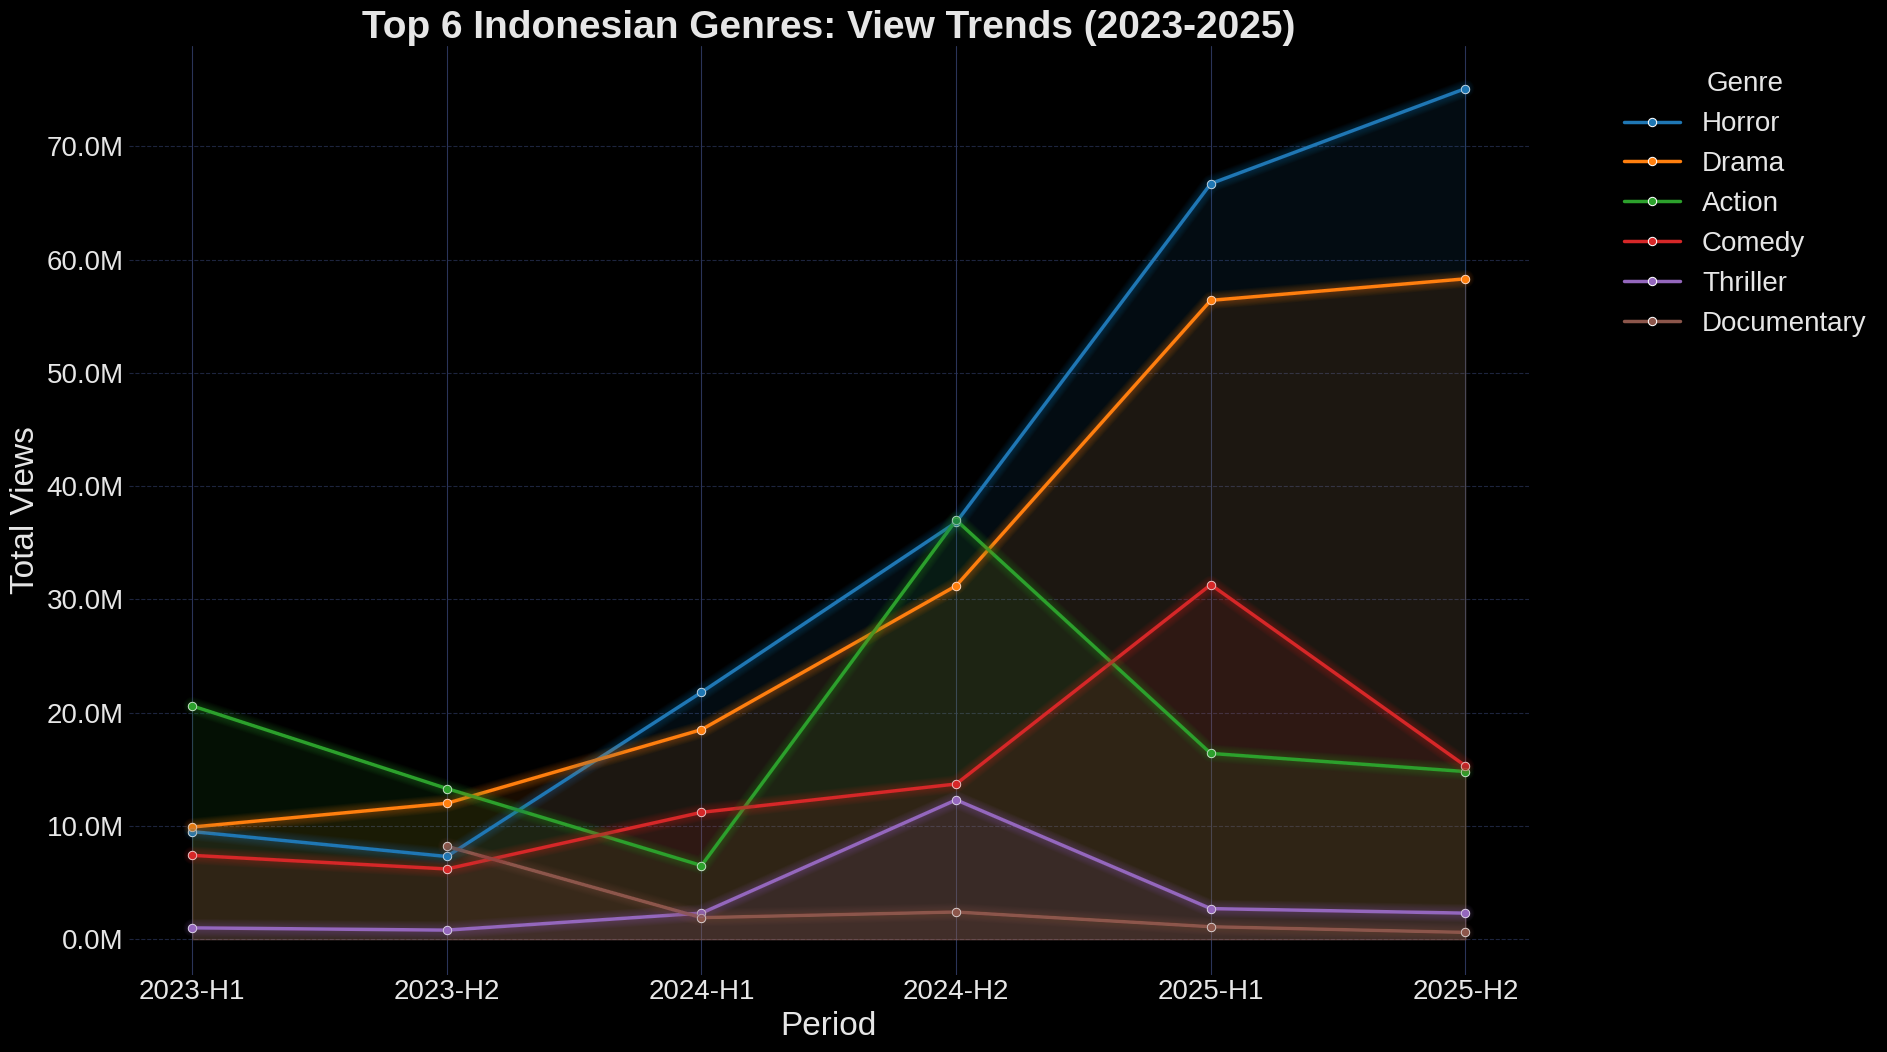

In [ ]:
# ── Config ────────────────────────────────────────────────────
INDO_TREND_N     = TOP_N_GENRES
INDO_TREND_TITLE = f'Top {TOP_N_GENRES} Indonesian Genres: View Trends (2023-2025)'

# ── Chart ─────────────────────────────────────────────────────
plot_trend_lines(views_indo, title=INDO_TREND_TITLE, top_n=INDO_TREND_N)


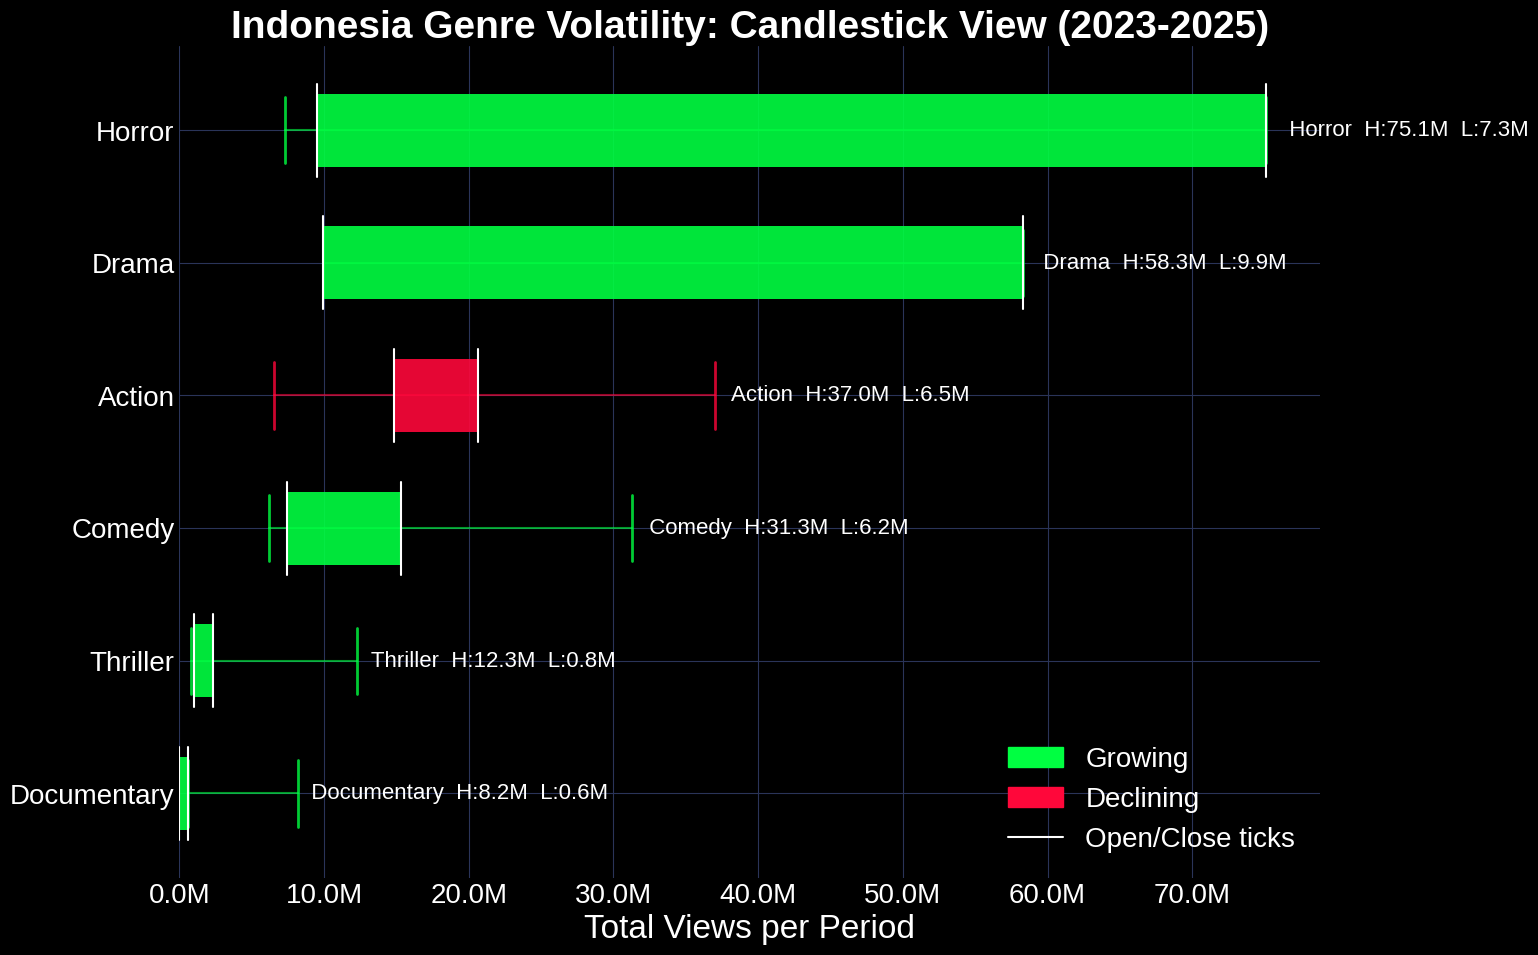

,genre,open,close,high,low
0,Documentary,0,"600,000","8,200,000","600,000"
1,Thriller,"1,000,000","2,300,000","12,300,000","800,000"
2,Comedy,"7,400,000","15,300,000","31,300,000","6,200,000"
3,Action,"20,600,000","14,800,000","37,000,000","6,500,000"
4,Drama,"9,900,000","58,300,000","58,300,000","9,900,000"
5,Horror,"9,500,000","75,100,000","75,100,000","7,300,000"


In [ ]:
# ── Config ────────────────────────────────────────────────────
INDO_CANDLE_N      = TOP_N_GENRES
INDO_CANDLE_TITLE  = 'Indonesia Genre Volatility: Candlestick View (2023-2025)'
# INDO_CALLOUTS = [
#     ('TOP DOMINATORS', 'Horror & Drama', C_GROWING),
#     ('MOST VOLATILE',  'Action',         C_DECLINING),
#     ('2ND MOST VOLATILE', 'Comedy',      C_THRESHOLD),
# ]
# INDO_FOOTNOTES = [
#     'Thriller spiked in 2024-H2\nbut lacked sustained momentum.',
#     'Horror and Drama showed the\nonly true structural growth.',
# ]

# ── Chart ─────────────────────────────────────────────────────
indo_candle_df = plot_candlestick(
    views_indo,
    title     = INDO_CANDLE_TITLE,
    top_n     = INDO_CANDLE_N,
    # callouts  = INDO_CALLOUTS,
    # footnotes = INDO_FOOTNOTES,
)
display(indo_candle_df[['genre','open','close','high','low']].style.format('{:,.0f}', subset=['open','close','high','low']))


# **Global Chart**

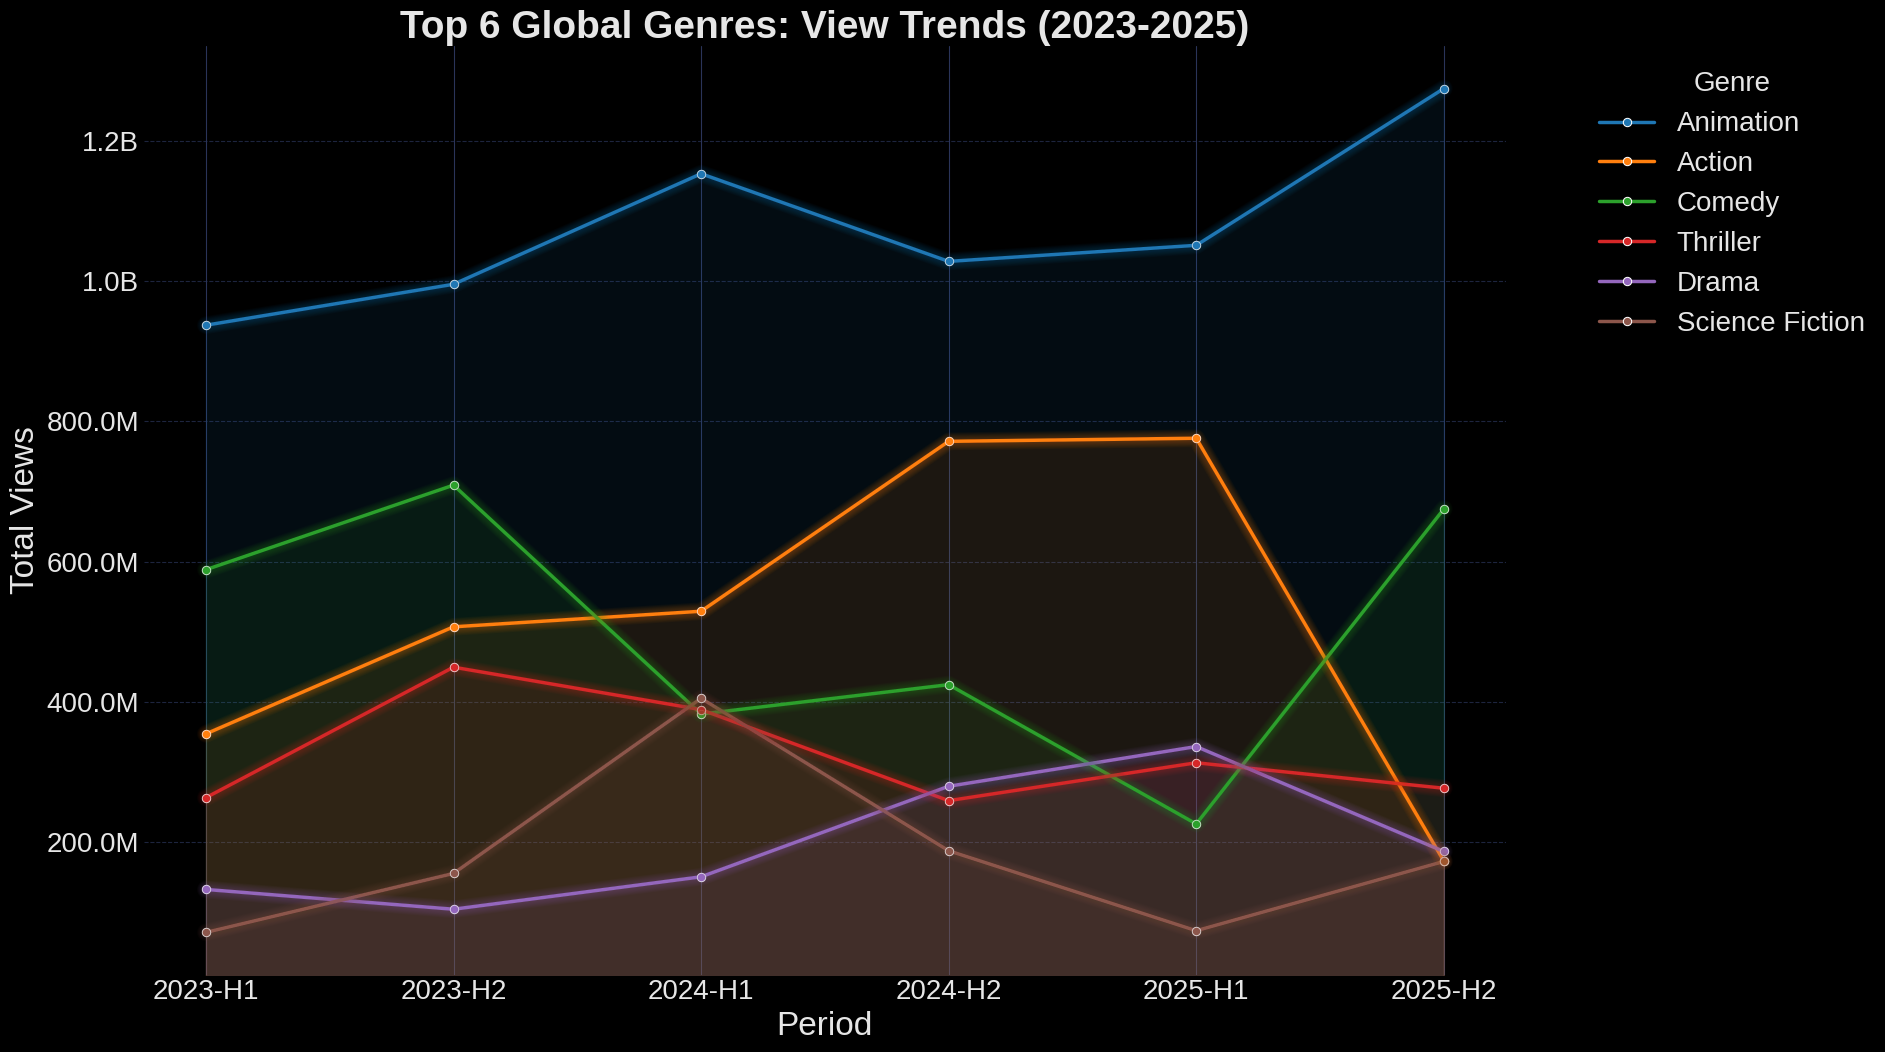

In [ ]:
# ── Config ────────────────────────────────────────────────────
GLOBAL_TREND_N     = TOP_N_GENRES
GLOBAL_TREND_TITLE = f'Top {TOP_N_GENRES} Global Genres: View Trends (2023-2025)'

# ── Chart ─────────────────────────────────────────────────────
plot_trend_lines(views_global, title=GLOBAL_TREND_TITLE, top_n=GLOBAL_TREND_N)


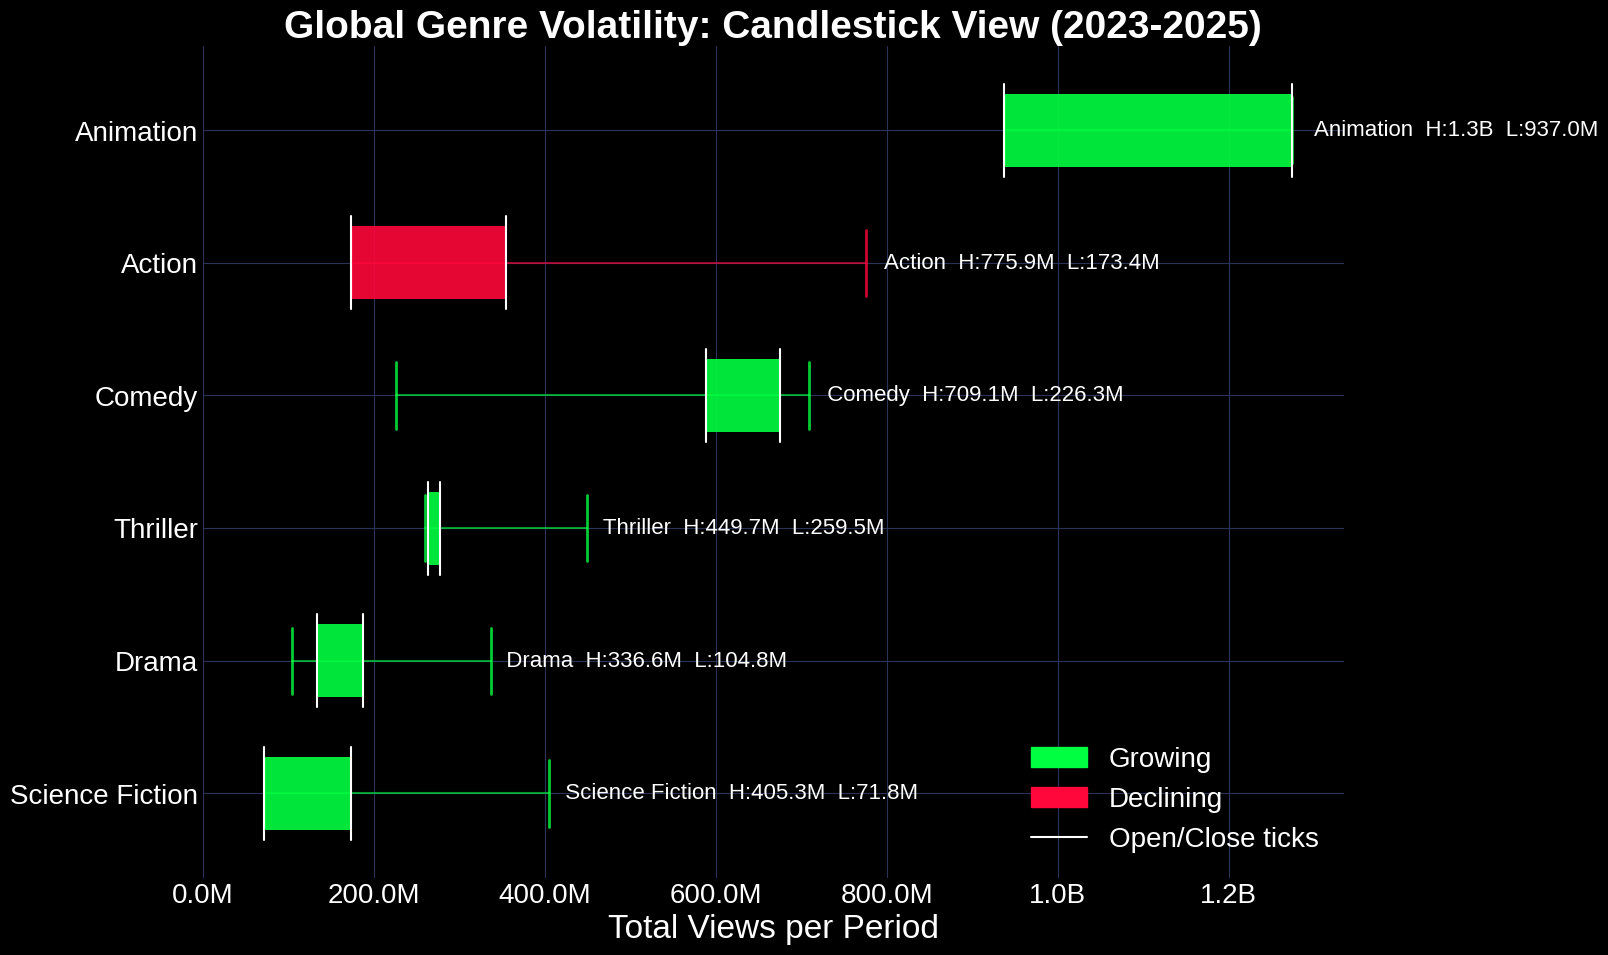

,genre,open,close,high,low
0,Science Fiction,"71,800,000","172,900,000","405,300,000","71,800,000"
1,Drama,"133,000,000","187,100,000","336,600,000","104,800,000"
2,Thriller,"263,800,000","277,200,000","449,700,000","259,500,000"
3,Comedy,"588,600,000","675,100,000","709,100,000","226,300,000"
4,Action,"354,700,000","173,400,000","775,900,000","173,400,000"
5,Animation,"936,966,000","1,274,200,000","1,274,200,000","936,966,000"


In [ ]:
# ── Config ────────────────────────────────────────────────────
GLOBAL_CANDLE_N     = TOP_N_GENRES
GLOBAL_CANDLE_TITLE = 'Global Genre Volatility: Candlestick View (2023-2025)'
GLOBAL_CALLOUTS = [
    ('MOST CONSISTENT GROWTH', 'Animation', C_GROWING),
    ('BIGGEST DECLINE',        'Action',    C_DECLINING),
    ('MOST VOLATILE',          'Comedy',    C_THRESHOLD),
]
GLOBAL_FOOTNOTES = [
    'Science Fiction spiked sharply\nbut lacked sustained momentum.',
    'Crime & Adventure declined steadily,\nwhile Drama and Thriller remained stable.',
]

# ── Chart ─────────────────────────────────────────────────────
global_candle_df = plot_candlestick(
    views_global,
    title     = GLOBAL_CANDLE_TITLE,
    top_n     = GLOBAL_CANDLE_N,
    # callouts  = GLOBAL_CALLOUTS,
    # footnotes = GLOBAL_FOOTNOTES,
)
display(global_candle_df[['genre','open','close','high','low']].style.format('{:,.0f}', subset=['open','close','high','low']))


# **Head To Head**

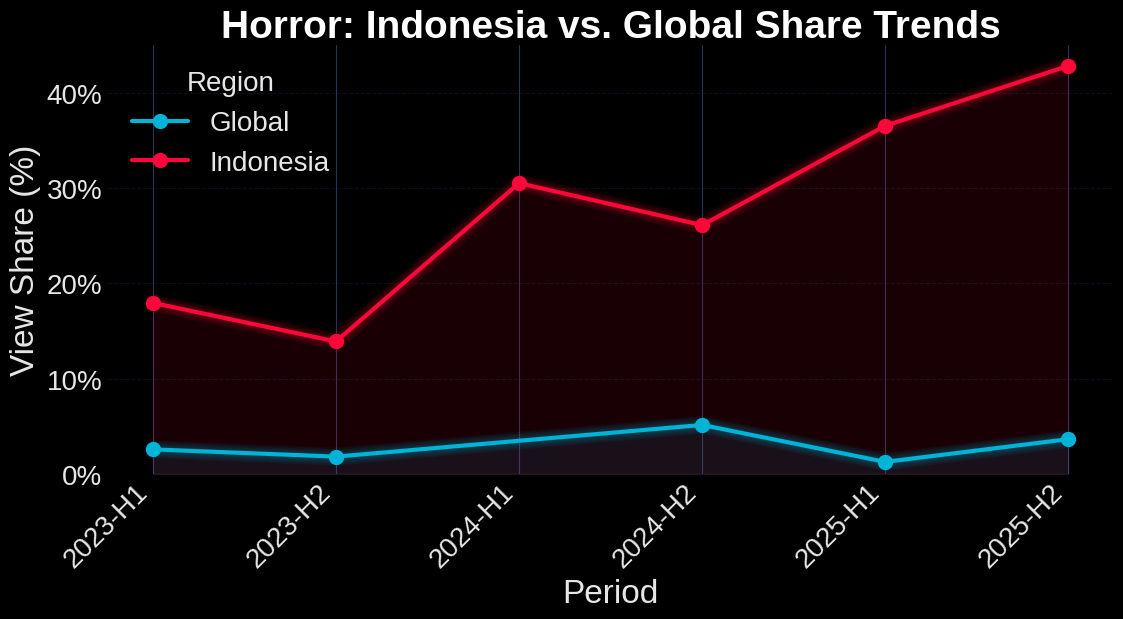

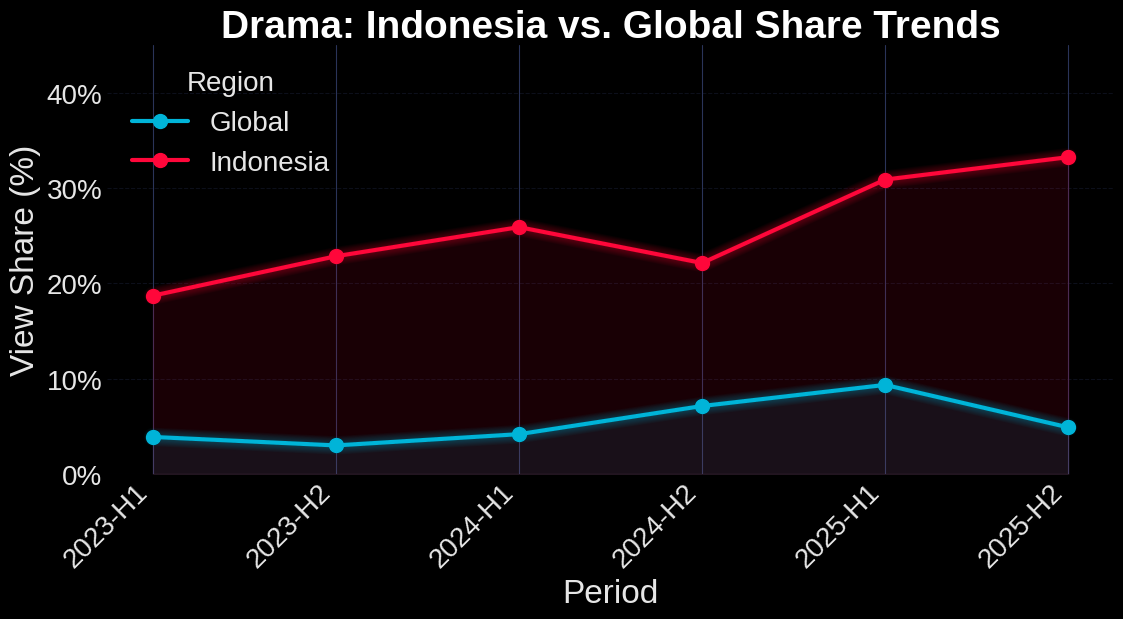

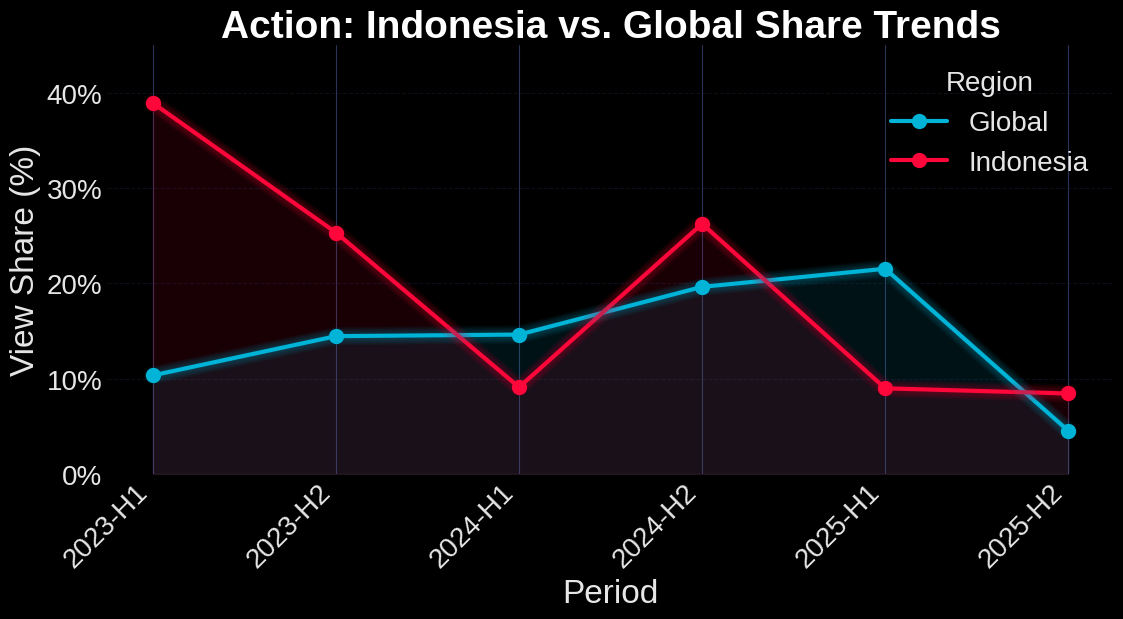

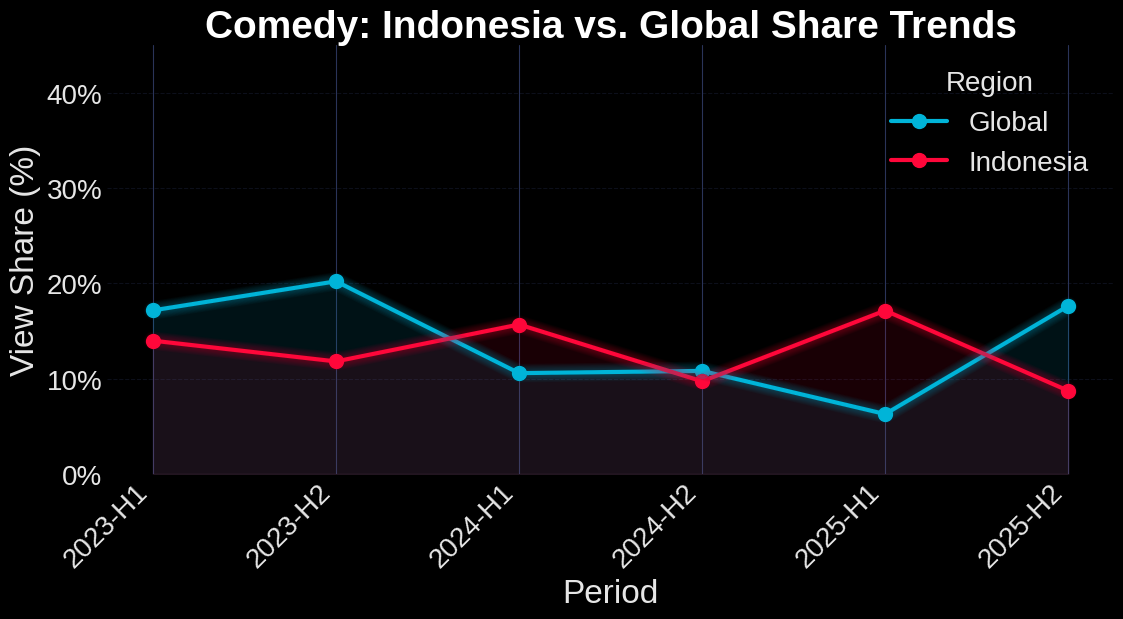

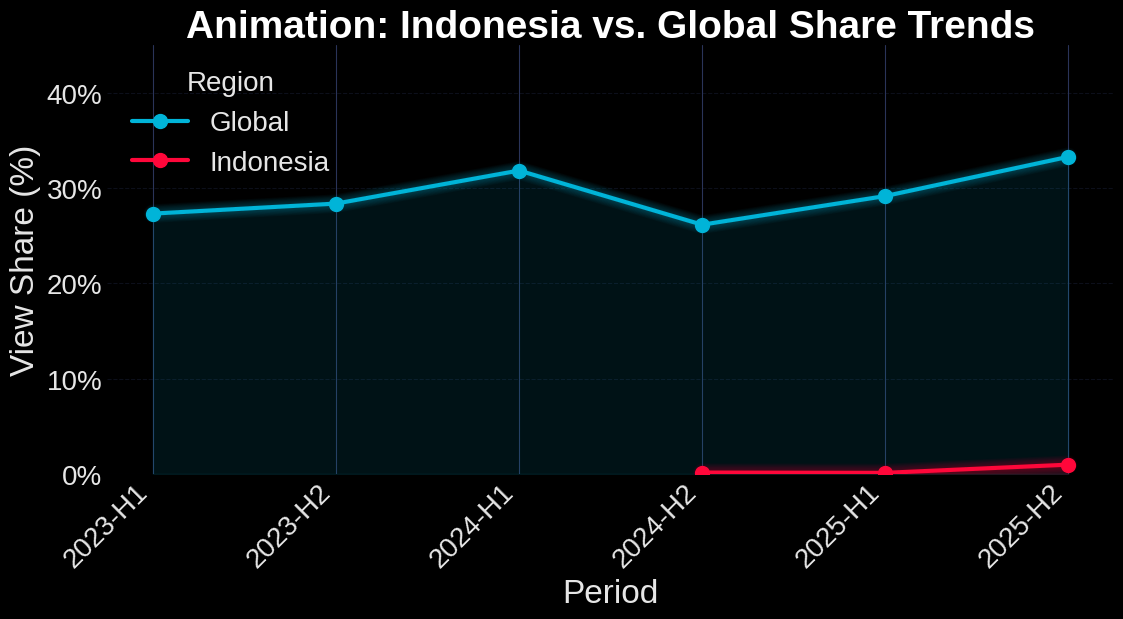

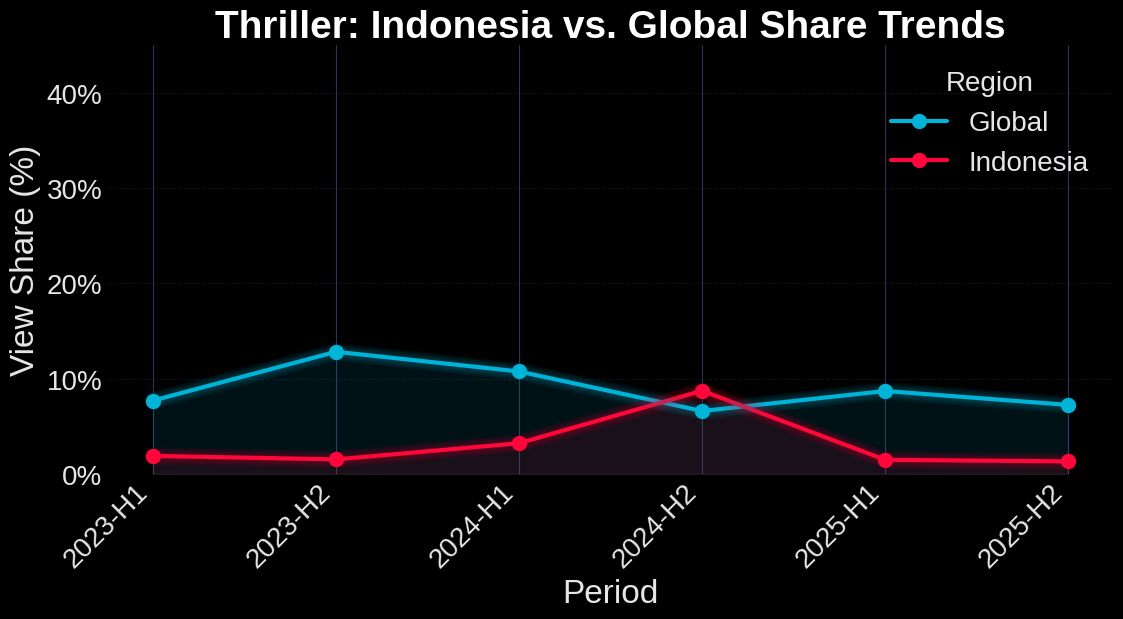

In [ ]:
# ── Config ────────────────────────────────────────────────────
HEAD2HEAD_GENRES    = ['Horror', 'Drama', 'Action', 'Comedy', 'Animation', 'Thriller']
HEAD2HEAD_MAX_SHARE = 0.45

# ── Chart ─────────────────────────────────────────────────────
# Now calling the individual plot function instead of the grid
plot_head2head_individual(
    combined_norm,
    genres    = HEAD2HEAD_GENRES,
    title_suffix = 'ID vs Global',
    max_share = HEAD2HEAD_MAX_SHARE
)

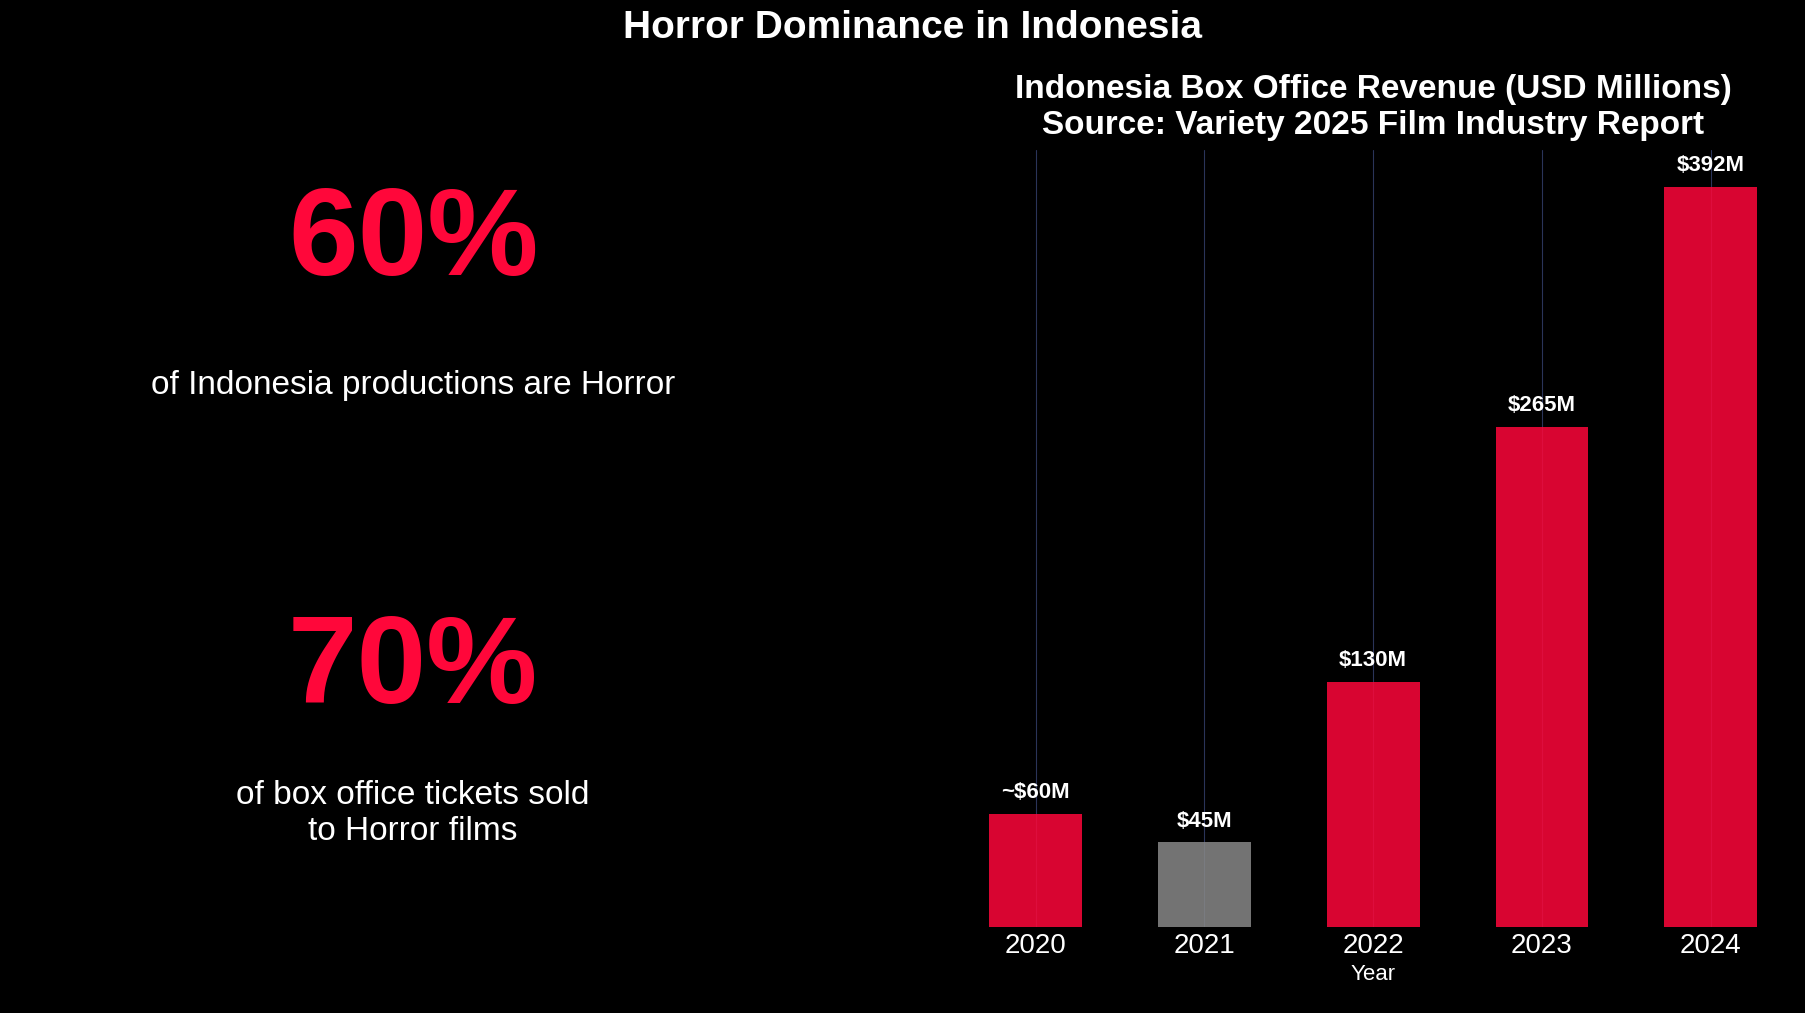

In [ ]:
# ── Config ────────────────────────────────────────────────────
# Source: Variety 2025 Film Industry Report
# 2021 is greyed out (COVID — cinemas closed)
HORROR_TITLE       = 'Horror Dominance in Indonesia'
HORROR_STAT_1_VAL  = '60%'
HORROR_STAT_1_TEXT = 'of Indonesia productions are Horror'
HORROR_STAT_2_VAL  = '70%'
HORROR_STAT_2_TEXT = 'of box office tickets sold\nto Horror films'
BOX_YEARS          = [2020, 2021, 2022, 2023, 2024]
BOX_VALUES         = [60,   45,   130,  265,  392]   # USD millions
BOX_COVID_YEAR     = 2021
BOX_SOURCE         = 'Indonesia Box Office Revenue (USD Millions)\nSource: Variety 2025 Film Industry Report'

# ── Chart ─────────────────────────────────────────────────────
plt.style.use('cyberpunk')
fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.suptitle(HORROR_TITLE, fontsize=FS_TITLE, fontweight='bold', color='white', y=0.97)

ax_s = fig.add_axes([0.03, 0.05, 0.42, 0.88])
ax_s.set_xlim(0, 1); ax_s.set_ylim(0, 1); ax_s.axis('off')
ax_s.text(0.5, 0.80, HORROR_STAT_1_VAL,  ha='center', va='center', fontsize=90, fontweight='bold', color=C_HIGHLIGHT)
ax_s.text(0.5, 0.65, HORROR_STAT_1_TEXT, ha='center', va='center', fontsize=FS_LABEL, color='white')
ax_s.text(0.5, 0.35, HORROR_STAT_2_VAL,  ha='center', va='center', fontsize=90, fontweight='bold', color=C_HIGHLIGHT)
ax_s.text(0.5, 0.20, HORROR_STAT_2_TEXT, ha='center', va='center', fontsize=FS_LABEL, color='white')

ax_b = fig.add_axes([0.52, 0.12, 0.44, 0.72])
bar_colors = [C_MUTED if y == BOX_COVID_YEAR else C_HIGHLIGHT for y in BOX_YEARS]
bars = ax_b.bar(BOX_YEARS, BOX_VALUES, color=bar_colors, alpha=0.85, width=0.55)
for bar, val, yr in zip(bars, BOX_VALUES, BOX_YEARS):
    lbl = f'~${val}M' if yr == BOX_YEARS[0] else f'${val}M'
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
              lbl, ha='center', va='bottom', color='white', fontsize=FS_TEXT, fontweight='bold')

ax_b.set_title(BOX_SOURCE, color='white', fontsize=FS_LABEL, fontweight='bold', pad=12)
ax_b.set_xlabel('Year', color='white', fontsize=FS_TEXT)
ax_b.tick_params(colors='white', labelsize=FS_TICK)
ax_b.set_xticks(BOX_YEARS); ax_b.set_yticks([])
for spine in ['top','right','left']: ax_b.spines[spine].set_visible(False)
ax_b.spines['bottom'].set_color('white')
finish_plot(fig, tight=False)


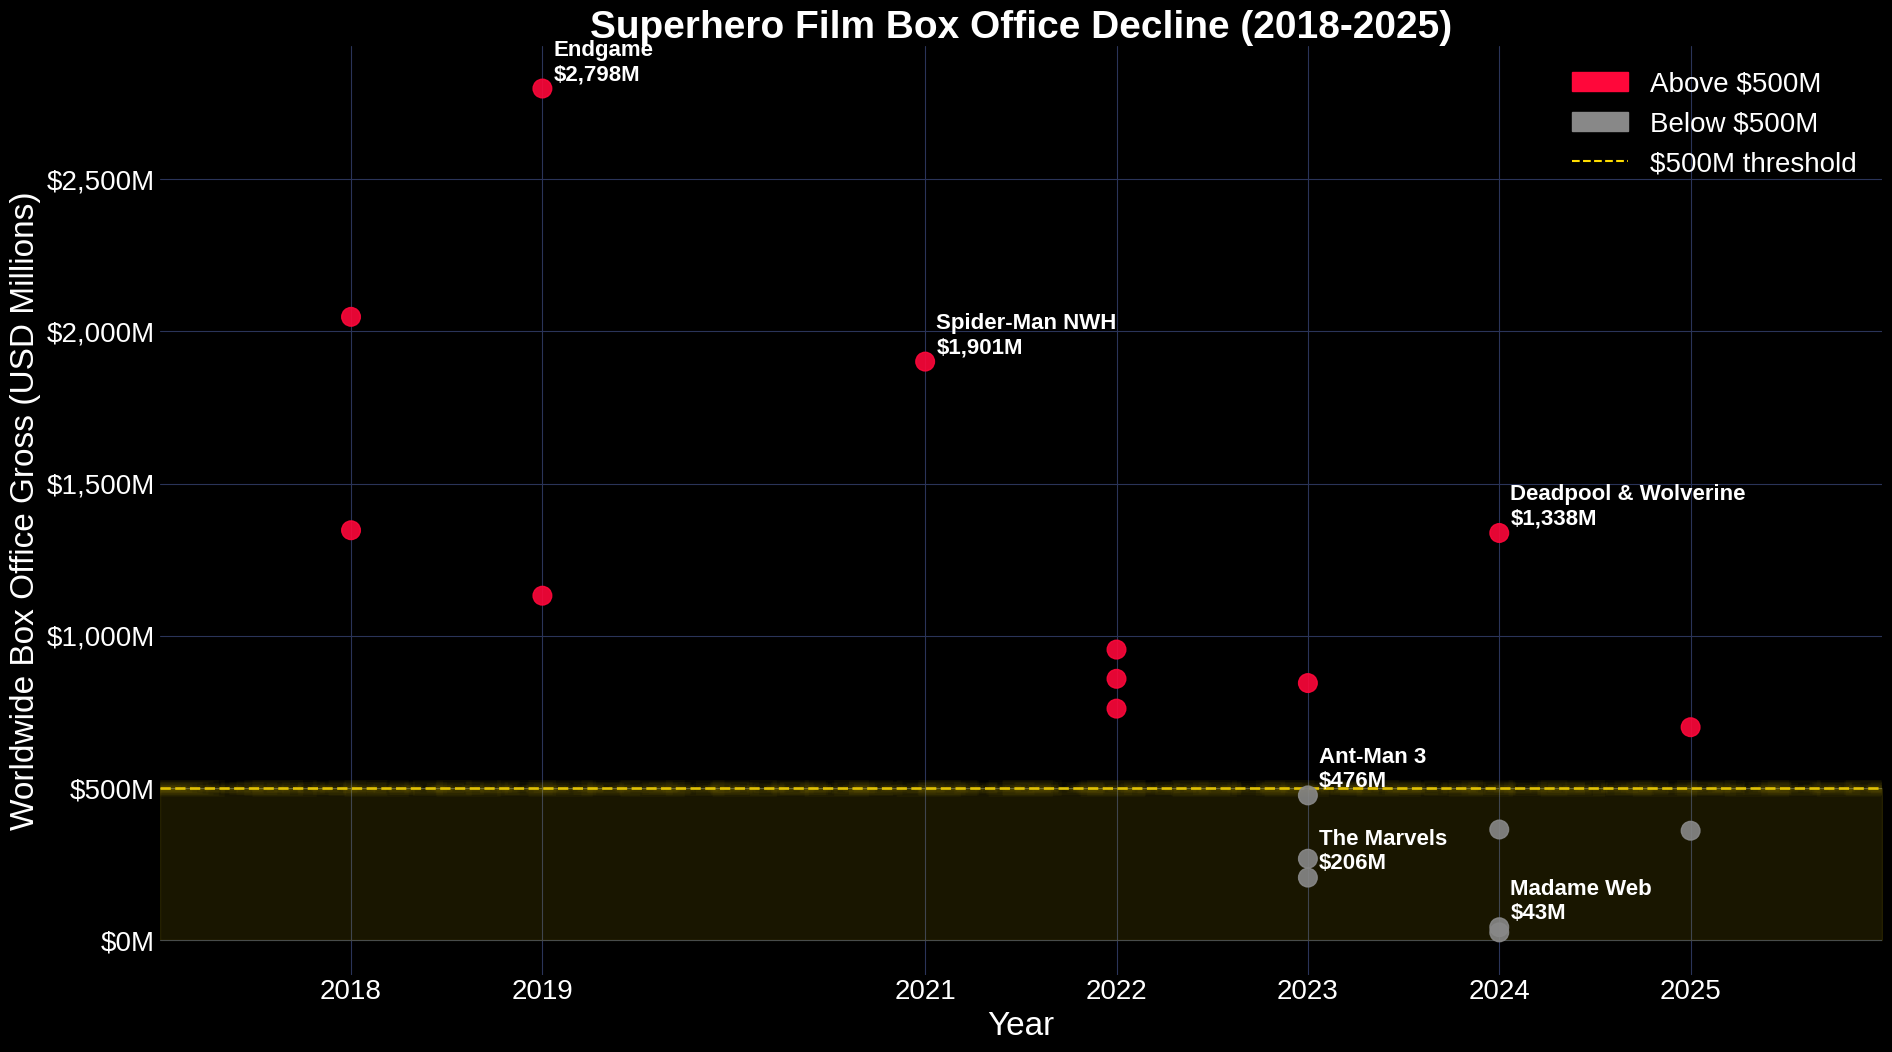

In [ ]:
# ── Config ────────────────────────────────────────────────────
# Source: Box Office Mojo / The Numbers
SUPERHERO_TITLE  = 'Superhero Film Box Office Decline (2018-2025)'
SUPERHERO_THRESHOLD = 500   # USD millions — industry "hit" benchmark

# (year, title, worldwide_gross_usd_millions)
SUPERHERO_FILMS = [
    (2018, 'Infinity War',          2048),
    (2018, 'Black Panther',         1347),
    (2019, 'Endgame',               2798),
    (2019, 'Spider-Man FFH',        1132),
    (2021, 'Spider-Man NWH',        1901),
    (2022, 'Dr Strange 2',           955),
    (2022, 'Black Panther 2',        859),
    (2022, 'Thor 4',                 761),
    (2023, 'Guardians 3',            845),
    (2023, 'Ant-Man 3',              476),
    (2023, 'The Flash',              268),
    (2023, 'The Marvels',            206),
    (2024, 'Deadpool & Wolverine',  1338),
    (2024, 'Captain America 4',      364),
    (2024, 'Kraven',                  26),
    (2024, 'Madame Web',              43),
    (2025, 'Superman',               700),
    (2025, 'Thunderbolts*',          360),
]
# Films to annotate on the chart (add/remove titles here)
LABEL_FILMS = {'Endgame', 'Ant-Man 3', 'The Marvels', 'Deadpool & Wolverine', 'Madame Web', 'Spider-Man NWH'}

# ── Chart ─────────────────────────────────────────────────────
years = [f[0] for f in SUPERHERO_FILMS]
gross = [f[2] for f in SUPERHERO_FILMS]

plt.style.use('cyberpunk')
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
fig.set_facecolor(C_BG); ax.set_facecolor(C_BG)

dot_colors = [C_HIGHLIGHT if g >= SUPERHERO_THRESHOLD else C_MUTED for g in gross]
ax.scatter(years, gross, c=dot_colors, s=180, zorder=5, alpha=0.9)
ax.set_xlim(min(years) - 1, max(years) + 1)

for yr, title, g in SUPERHERO_FILMS:
    if title in LABEL_FILMS:
        ax.annotate(f'{title}\n${g:,}M', xy=(yr, g), xytext=(8, 6),
                    textcoords='offset points', fontsize=FS_TEXT, color='white', fontweight='bold')

ax.axhline(SUPERHERO_THRESHOLD, color=C_THRESHOLD, linestyle='--', linewidth=2, alpha=0.8)
ax.set_ylabel('Worldwide Box Office Gross (USD Millions)', color='white', fontsize=FS_LABEL)
ax.set_xlabel('Year', color='white', fontsize=FS_LABEL)
ax.tick_params(colors='white', labelsize=FS_TICK)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
ax.set_xticks(sorted(set(years)))
ax.legend(handles=[
    mpatches.Patch(color=C_HIGHLIGHT, label=f'Above ${SUPERHERO_THRESHOLD}M'),
    mpatches.Patch(color=C_MUTED,     label=f'Below ${SUPERHERO_THRESHOLD}M'),
    plt.Line2D([0],[0], color=C_THRESHOLD, linestyle='--', label=f'${SUPERHERO_THRESHOLD}M threshold'),
], loc='upper right', fontsize=FS_LEGEND, facecolor='#111111', labelcolor='white')
ax.set_title(SUPERHERO_TITLE, fontweight='bold', fontsize=FS_TITLE, color='white')
try: mplcyberpunk.add_glow_effects()
except Exception: pass
finish_plot(fig, glow=False)


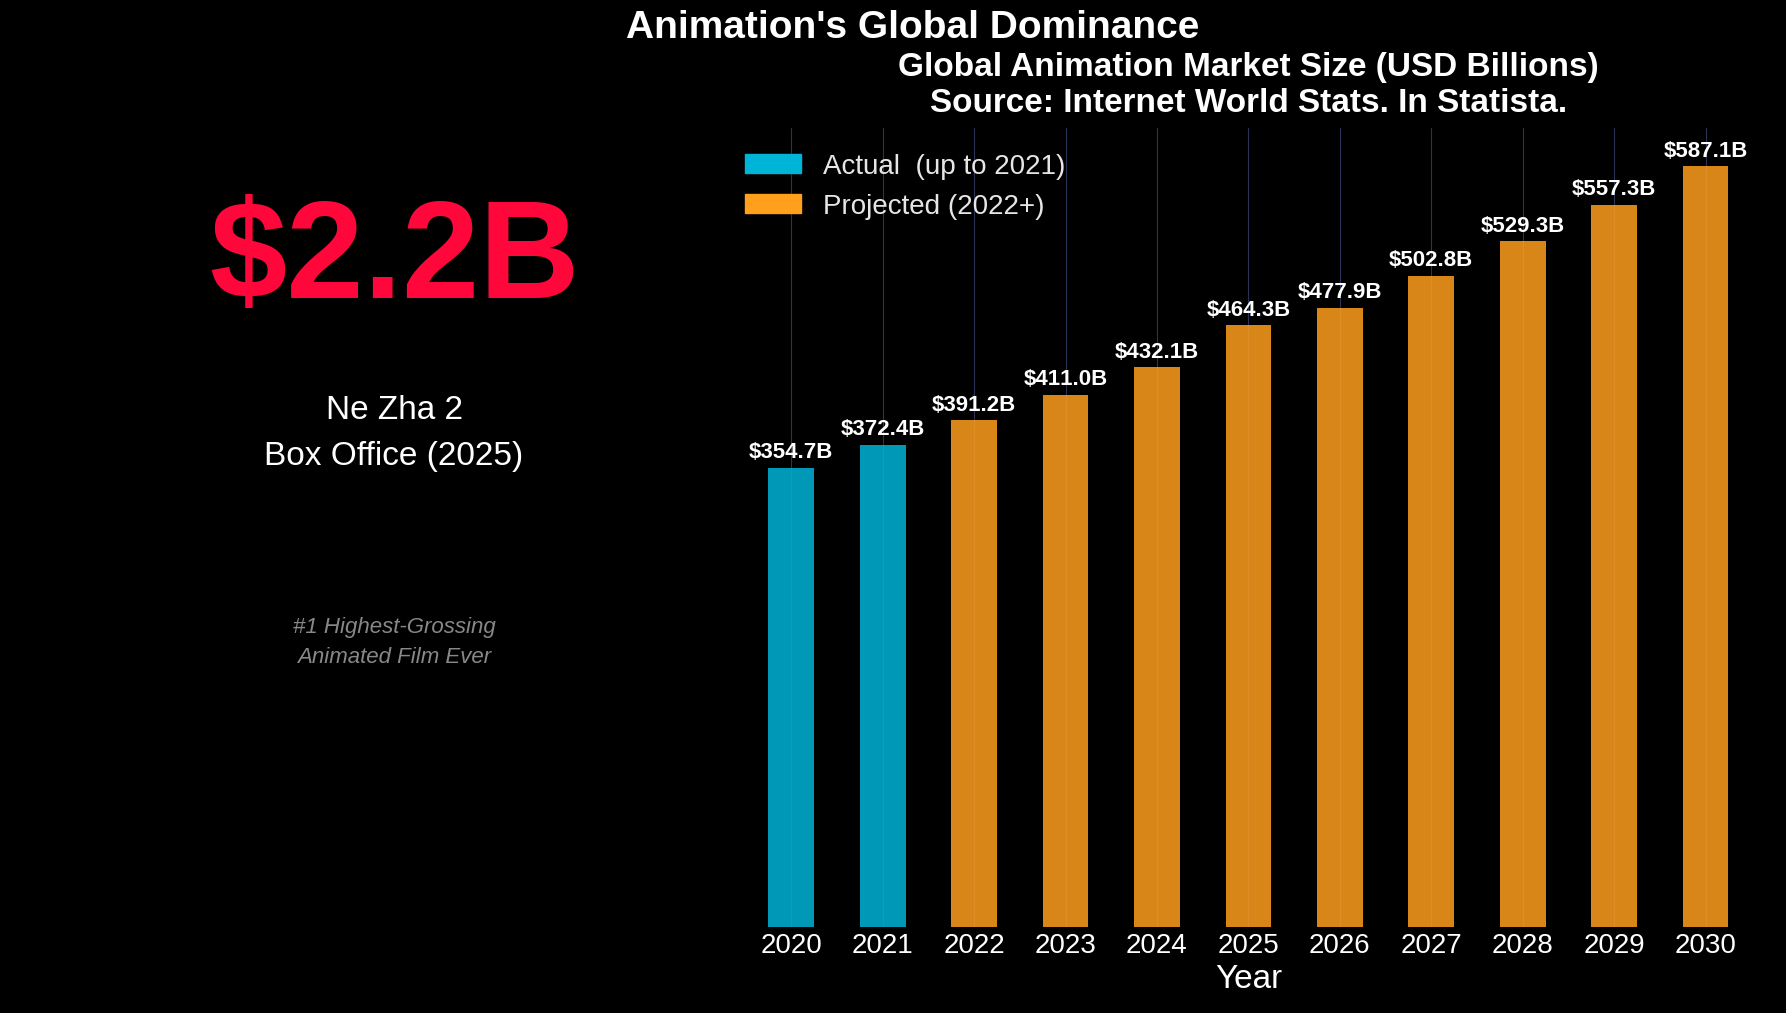

In [ ]:
# ── Config ────────────────────────────────────────────────────
# Source: Internet World Stats in Statista
ANIM_TITLE       = "Animation's Global Dominance"
ANIM_STAT_VAL    = '$2.2B'
ANIM_STAT_LABEL  = 'Ne Zha 2\nBox Office (2025)'
ANIM_STAT_SUB    = '#1 Highest-Grossing\nAnimated Film Ever'
ANIM_BAR_TITLE   = 'Global Animation Market Size (USD Billions)\nSource: Internet World Stats. In Statista.'
ANIM_ACTUAL_CUTOFF = 2021    # years <= this are 'actual'; after are 'projected'

ANIM_YEARS  = [2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030]
ANIM_VALUES = [354.7, 372.4, 391.2, 411.0, 432.1, 464.3, 477.9, 502.8, 529.3, 557.3, 587.1]

# ── Chart ─────────────────────────────────────────────────────
plt.style.use('cyberpunk')
fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.suptitle(ANIM_TITLE, fontsize=FS_TITLE, fontweight='bold', color='white', y=0.97)

ax_s = fig.add_axes([0.03, 0.05, 0.40, 0.88])
ax_s.set_xlim(0, 1); ax_s.set_ylim(0, 1); ax_s.axis('off')
ax_s.text(0.5, 0.78, ANIM_STAT_VAL,   ha='center', va='center', fontsize=100, fontweight='bold', color=C_HIGHLIGHT)
ax_s.text(0.5, 0.60, ANIM_STAT_LABEL, ha='center', va='center', fontsize=FS_LABEL, color='white', linespacing=1.6)
ax_s.text(0.5, 0.38, ANIM_STAT_SUB,   ha='center', va='center', fontsize=16, color=C_MUTED, style='italic', linespacing=1.6)

ax_b = fig.add_axes([0.40, 0.12, 0.55, 0.74])
bar_colors = [C_ACTUAL if y <= ANIM_ACTUAL_CUTOFF else C_PROJECTED for y in ANIM_YEARS]
bars = ax_b.bar(ANIM_YEARS, ANIM_VALUES, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, ANIM_VALUES):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
              f'${val}B', ha='center', va='bottom', color='white', fontsize=FS_TEXT, fontweight='bold')

ax_b.set_title(ANIM_BAR_TITLE, color='white', fontsize=FS_LABEL, fontweight='bold', pad=12)
ax_b.set_xlabel('Year', color='white', fontsize=FS_LABEL)
ax_b.set_xticks(ANIM_YEARS)
ax_b.tick_params(colors='white', labelsize=FS_TICK)
ax_b.set_yticks([])
for spine in ['top','right','left']: ax_b.spines[spine].set_visible(False)
ax_b.spines['bottom'].set_color('white')
ax_b.legend(handles=[
    mpatches.Patch(color=C_ACTUAL,    label=f'Actual  (up to {ANIM_ACTUAL_CUTOFF})'),
    mpatches.Patch(color=C_PROJECTED, label=f'Projected ({ANIM_ACTUAL_CUTOFF+1}+)'),
], loc='upper left', fontsize=FS_LEGEND)
finish_plot(fig, tight=False)


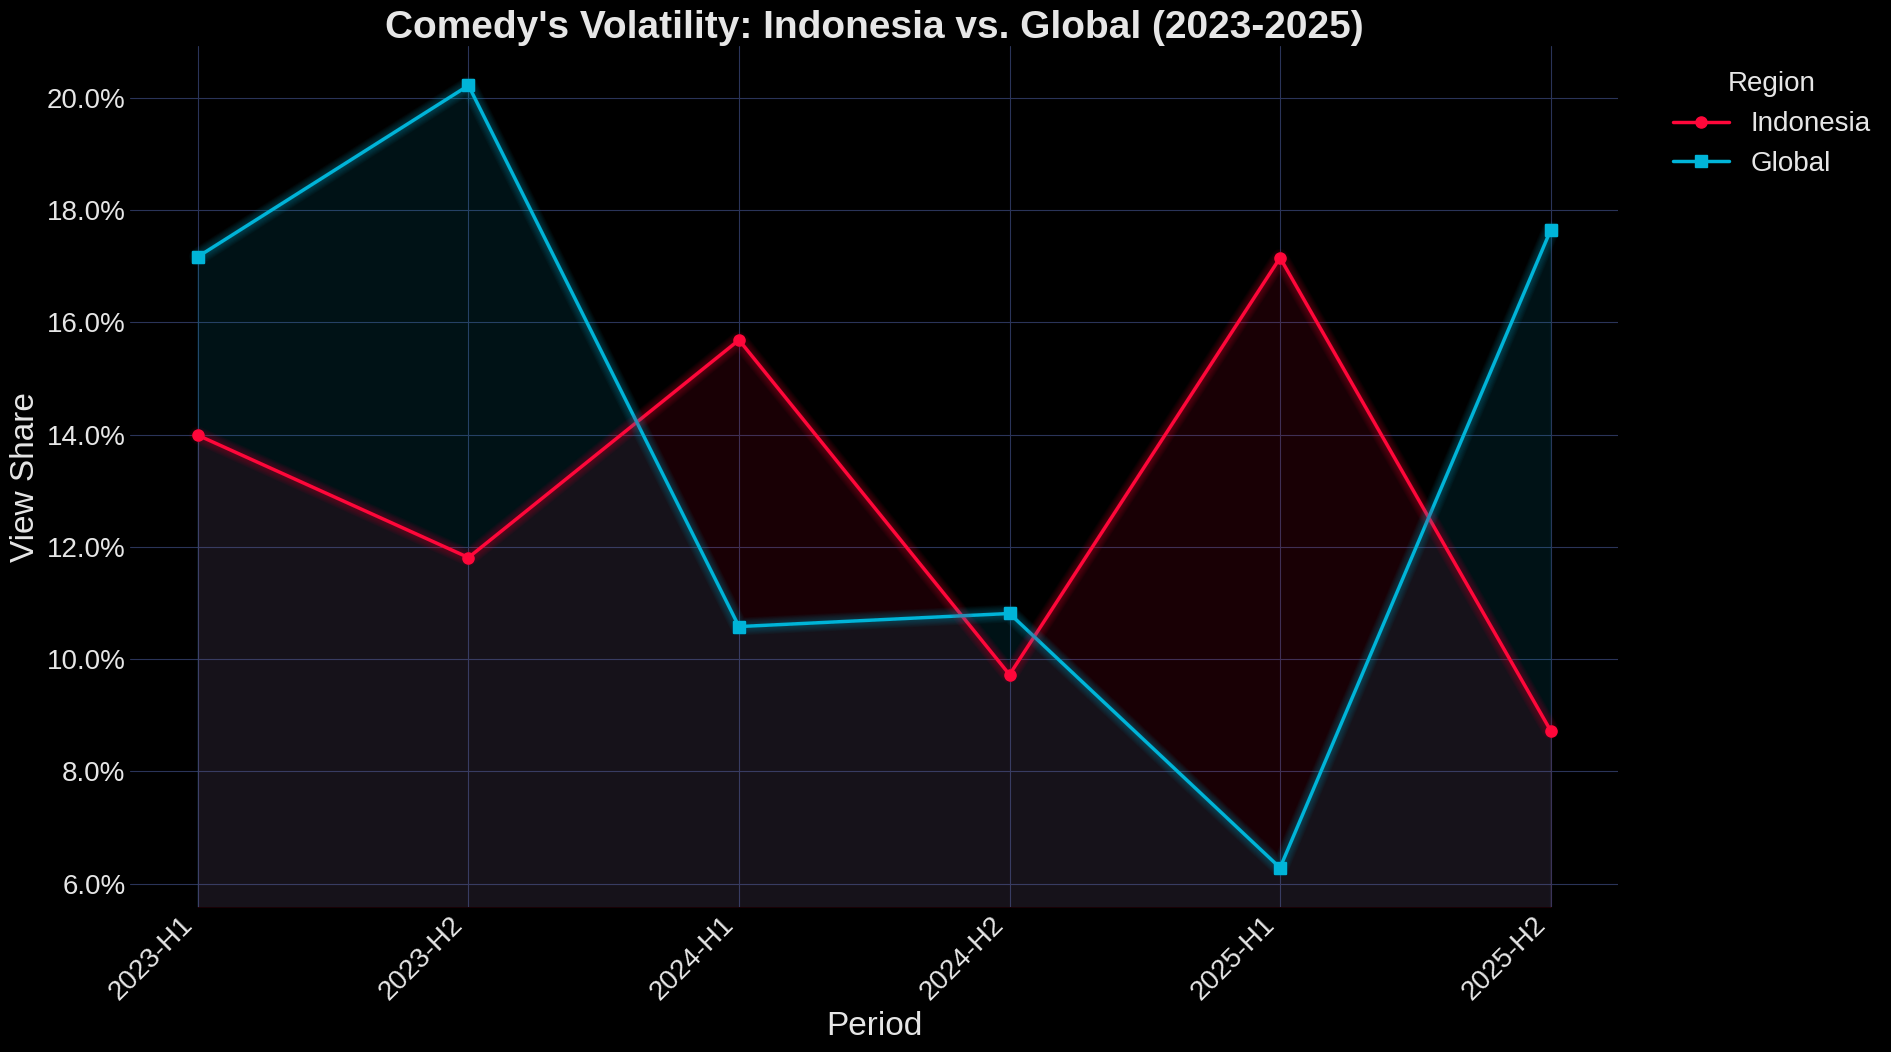

In [ ]:
# ── Config ────────────────────────────────────────────────────
COMEDY_GENRE = 'Comedy'   # change to any genre to compare
COMEDY_TITLE = f"{COMEDY_GENRE}'s Volatility: Indonesia vs. Global (2023-2025)"

# ── Chart ─────────────────────────────────────────────────────
c_indo = views_indo_norm[views_indo_norm['genre'] == COMEDY_GENRE].sort_values('period')
c_glb  = views_global_norm[views_global_norm['genre'] == COMEDY_GENRE].sort_values('period')

x = list(range(len(PERIOD_ORDER)))

fig, ax = new_fig()
ax.plot(x, c_indo['views_share'].values, 'o-', color=C_INDO,   lw=2.5, markersize=8, label='Indonesia')
ax.plot(x, c_glb['views_share'].values,  's-', color=C_GLOBAL, lw=2.5, markersize=8, label='Global')
ax.set_xticks(x)
ax.set_xticklabels(PERIOD_ORDER, rotation=45, ha='right', fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.set_xlabel('Period', fontsize=FS_LABEL)
ax.set_ylabel('View Share', fontsize=FS_LABEL)
ax.set_title(COMEDY_TITLE, fontweight='bold', fontsize=FS_TITLE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:.1%}'))
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=FS_LEGEND, title_fontsize=FS_LEGEND)
finish_plot(fig)


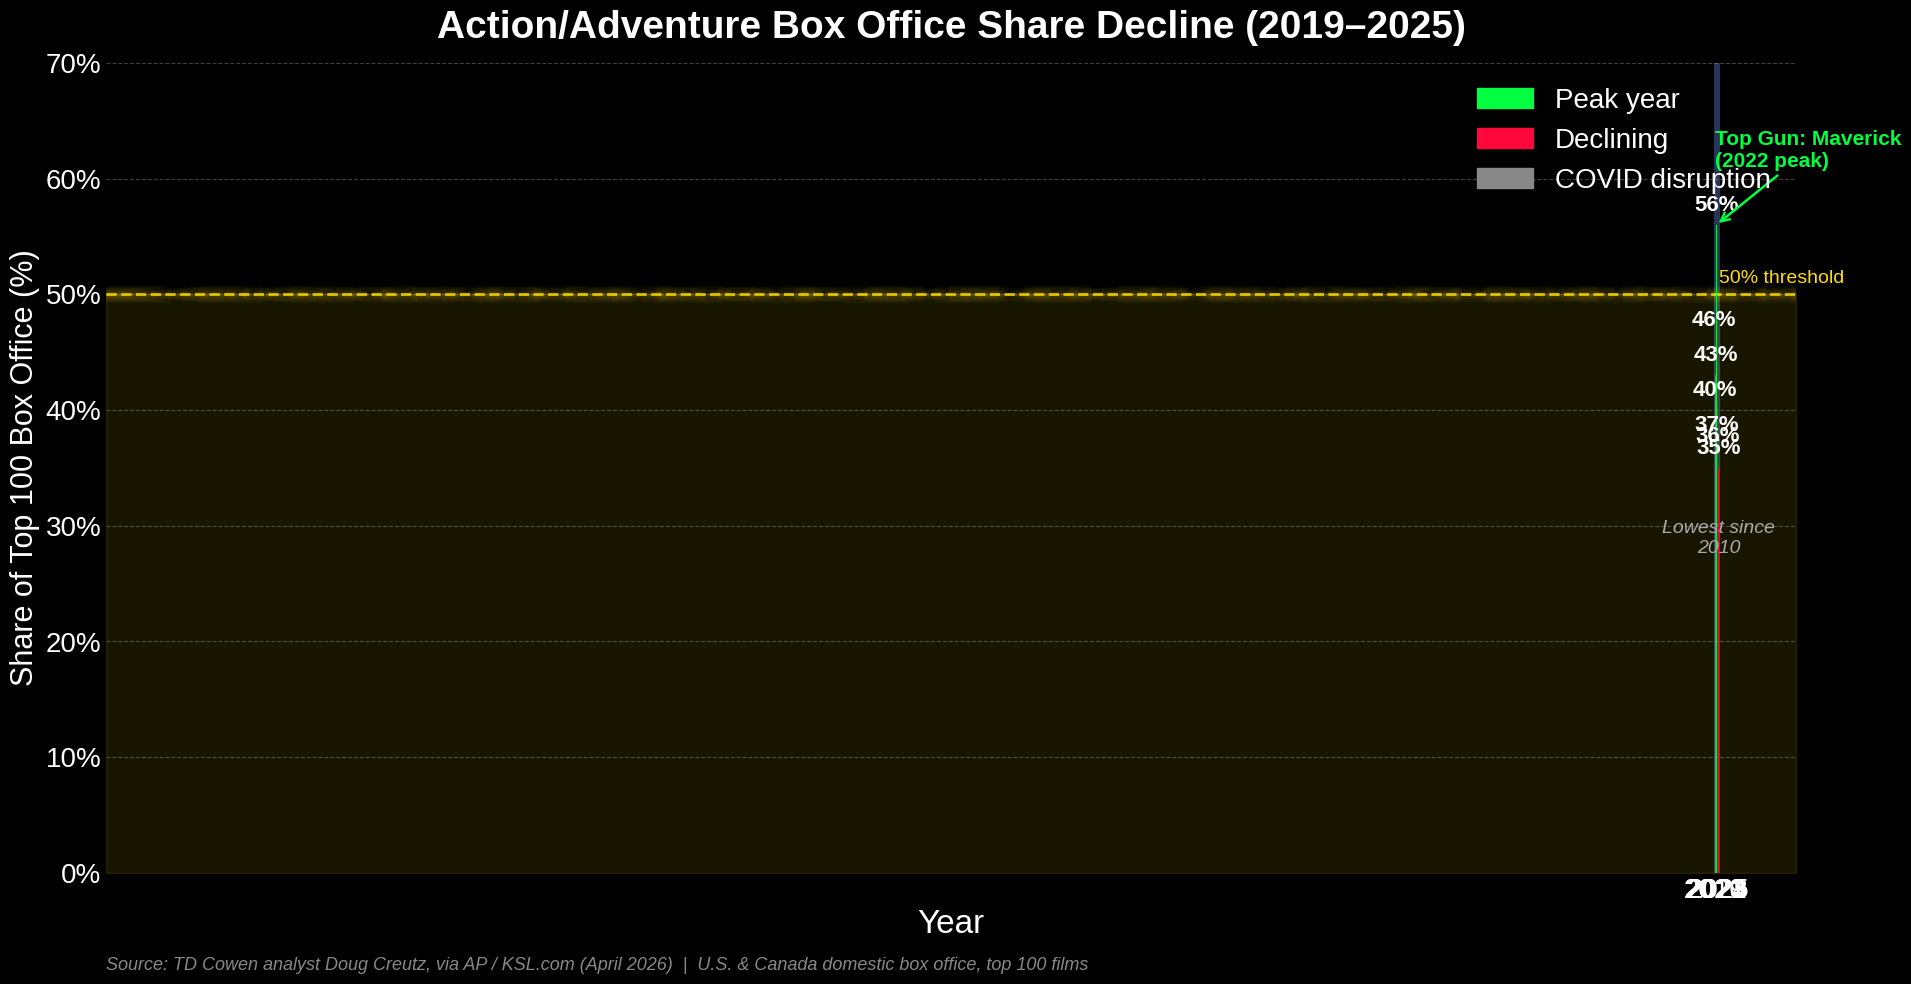

In [ ]:
# ══════════════════════════════════════════════════════════════
#  SLIDE 8 — Action/Adventure Box Office Share Decline (2019–2025)
#  Source: TD Cowen analyst Doug Creutz, via AP / KSL.com (April 2026)
# ══════════════════════════════════════════════════════════════

# ── Config ────────────────────────────────────────────────────
ACTION_TITLE  = 'Action/Adventure Box Office Share Decline (2019–2025)'
ACTION_SOURCE = 'Source: TD Cowen analyst Doug Creutz, via AP / KSL.com (April 2026)  |  U.S. & Canada domestic box office, top 100 films'
ACTION_THRESHOLD     = 50      # % — historical dominance benchmark
ACTION_COVID_YEARS   = {2020, 2021}
ACTION_PEAK_YEAR     = 2022

# (year, share_%)
ACTION_DATA = [
    (2019, 46),
    (2020, 40),
    (2021, 43),
    (2022, 56),
    (2023, 37),
    (2024, 36),
    (2025, 35),
]

# ── Chart ─────────────────────────────────────────────────────
years  = [d[0] for d in ACTION_DATA]
shares = [d[1] for d in ACTION_DATA]

bar_colors = []
for y in years:
    if y in ACTION_COVID_YEARS:
        bar_colors.append(C_MUTED)
    elif y == ACTION_PEAK_YEAR:
        bar_colors.append(C_GROWING)
    else:
        bar_colors.append(C_DECLINING)

plt.style.use('cyberpunk')
fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.set_facecolor(C_BG)
ax = fig.add_axes([0.07, 0.12, 0.88, 0.75])
ax.set_facecolor(C_BG)

# glow layers
for yr, sh, c in zip(years, shares, bar_colors):
    ax.bar(yr, sh, color=c, alpha=0.15, width=0.7)
    ax.bar(yr, sh, color=c, alpha=0.25, width=0.6)

bars = ax.bar(years, shares, color=bar_colors, alpha=0.88, width=0.55, zorder=3)

# value labels
for bar, val in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val}%',
            ha='center', va='bottom',
            color='white', fontsize=FS_TEXT, fontweight='bold')

# threshold line
ax.axhline(ACTION_THRESHOLD, color=C_THRESHOLD, linewidth=2.0,
           linestyle='--', alpha=0.85, zorder=2)
ax.text(years[-1] + 0.3, ACTION_THRESHOLD + 0.6,
        f'{ACTION_THRESHOLD}% threshold',
        color=C_THRESHOLD, fontsize=FS_TEXT - 2, va='bottom', ha='left')

# annotations
ax.annotate('Top Gun: Maverick\n(2022 peak)',
            xy=(2022, 56), xytext=(2020.4, 61),
            color=C_GROWING, fontsize=FS_TEXT - 1, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_GROWING, lw=1.8))

ax.text(2025, 30.5,
        'Lowest since\n2010',
        ha='center', va='top',
        color='#aaaaaa', fontsize=FS_TEXT - 2, style='italic')

# legend
p_peak    = mpatches.Patch(color=C_GROWING,   label='Peak year')
p_decline = mpatches.Patch(color=C_DECLINING, label='Declining')
p_covid   = mpatches.Patch(color=C_MUTED,     label='COVID disruption')
ax.legend(handles=[p_peak, p_decline, p_covid],
          loc='upper right', fontsize=FS_LEGEND,
          facecolor='#111111', edgecolor='#333333',
          labelcolor='white', framealpha=0.8)

# axes styling
ax.set_title(ACTION_TITLE, fontsize=FS_TITLE, fontweight='bold', color='white', pad=18)
ax.set_xlabel('Year', fontsize=FS_LABEL, color='white')
ax.set_ylabel('Share of Top 100 Box Office (%)', fontsize=FS_LABEL - 2, color='white')
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], fontsize=FS_TICK)
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.tick_params(axis='both', labelsize=FS_TICK, colors='white')
ax.grid(axis='y', linestyle='--', alpha=0.25, color='white')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#444444')

fig.text(0.07, 0.03, ACTION_SOURCE,
         fontsize=FS_TEXT - 3, color='#888888', style='italic')

finish_plot(fig, tight=False)